# Ejercicio 4: Sudoku como problema de búsqueda

---
## Problema
Rellenar un Sudoku de **9×9** cumpliendo las reglas: cada fila, columna y subcuadro de 3×3 debe contener los dígitos del 1 al 9 **sin repetición**.

---
## 1. Espacio de configuraciones $\Omega$

Una **configuración** es cualquier forma de rellenar las celdas vacías del tablero 9×9 con dígitos del 1 al 9.

Sea $k$ el número de celdas vacías en el tablero inicial. Cada celda vacía puede tomar un valor en $\{1,2,\ldots,9\}$, por lo que:

$$|\Omega| = 9^k$$

Para el Sudoku del laboratorio, hay **51 celdas vacías** y **30 pistas dadas**. Entonces:

$$|\Omega| = 9^{51} pprox 4.64 \times 10^{48}$$

La gran mayoría de esas configuraciones no satisface las restricciones del problema. El número total de tableros de Sudoku completos válidos es aproximadamente $6.67 \times 10^{21}$.

| Concepto | Valor |
|---|---|
| Tamaño del tablero | 9 × 9 = 81 celdas |
| Celdas dadas (pistas) | 30 |
| Celdas vacías $k$ | 51 |
| $|\Omega|$ (sin restricciones) | $9^{51} pprox 4.64 \times 10^{48}$ |
| Sudokus válidos completos | $\approx 6.67 \times 10^{21}$ |

---
## 2. Descripción de las configuraciones

Cada configuración se representa como una **matriz** de 9×9:

$$M n 0,1,2,dots,9^{9 	imes 9}$$

donde $M_{i,j} = 0$ indica una celda vacía, y $M_{i,j} n 1,dots,9$ indica un valor asignado.

- **Estado inicial:** la matriz con los valores dados y ceros en las celdas vacías.
- **Estado meta:** una matriz completamente llena que satisface todas las restricciones.
- **Transición:** asignar un valor $v n 1,dots,9$ a una celda vacía $(i,j)$.

---
## 3. Función de costo o métrica

A diferencia del TSP, el Sudoku es un **problema de satisfacción de restricciones (CSP)** y no un problema de optimización. Sin embargo, puede definirse una métrica que cuente cuántas restricciones son violadas:

$$f(M) = nderbrace{um_{i=0}^{8} 	ext{conflictos}(	ext{fila}_i)}_{	ext{filas}} + nderbrace{um_{j=0}^{8} 	ext{conflictos}(	ext{columna}_j)}_{	ext{columnas}} + nderbrace{um_{b=0}^{8} 	ext{conflictos}(	ext{subcuadro}_b)}_{	ext{subcuadros 3×3}}$$

donde $	ext{conflictos}(S) = |S| - |	ext{valores únicos en } S|$ considerando solo celdas distintas de cero.

El objetivo es encontrar un tablero $M^*$ tal que $f(M^*) = 0$.

---
## 4. Implementación

In [1]:
# ============================================================
# Importaciones y configuración general
# ============================================================
from collections import defaultdict
from pathlib import Path
import copy

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

IMAGES_DIR = Path('imagenes')
IMAGES_DIR.mkdir(exist_ok=True)

print('Librerías cargadas y carpeta de imágenes preparada.')

Librerías cargadas y carpeta de imágenes preparada.


### 4.1 Tablero inicial del laboratorio

In [2]:
# ============================================================
# Tablero inicial y tamaño del espacio de configuraciones
# ============================================================
board_initial = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

given = sum(1 for row in board_initial for value in row if value != 0)
empty = 81 - given
omega_approx = 9.0 ** empty

print(f'Celdas dadas (pistas): {given}')
print(f'Celdas vacías (k): {empty}')
print(f'|Ω| = 9^{empty} ≈ {omega_approx:.3e}')

Celdas dadas (pistas): 30
Celdas vacías (k): 51
|Ω| = 9^51 ≈ 4.638e+48


### 4.2 Función para visualizar el tablero

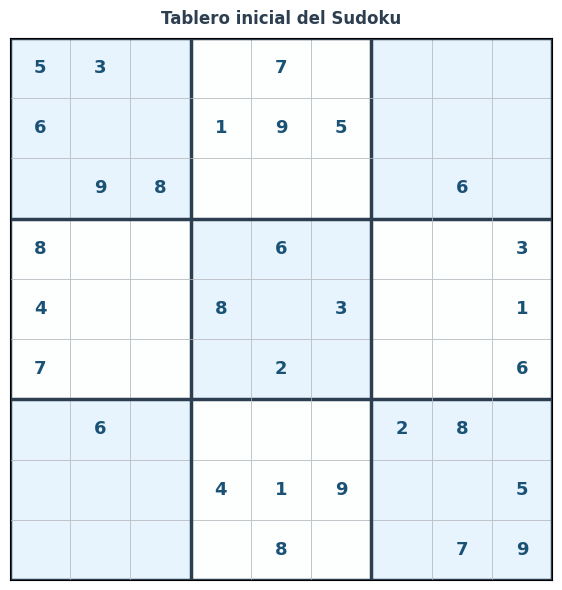

In [3]:
# ============================================================
# Visualización del tablero de Sudoku
# ============================================================
def draw_sudoku(board, title='Sudoku', given_board=None, ax=None, highlight_cells=None, save_path=None):
    """Dibuja un tablero de Sudoku."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    ax.set_facecolor('#FAFAFA')
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_aspect('equal')

    for row in range(9):
        for col in range(9):
            box_r, box_c = row // 3, col // 3
            background = '#E8F4FD' if (box_r + box_c) % 2 == 0 else '#FDFEFE'
            if highlight_cells and (row, col) in highlight_cells:
                background = '#FDEBD0'
            rect = plt.Rectangle(
                (col, 8 - row), 1, 1,
                facecolor=background, edgecolor='#BDC3C7', linewidth=0.5
            )
            ax.add_patch(rect)

    for row in range(9):
        for col in range(9):
            value = board[row][col]
            if value != 0:
                is_given = given_board is not None and given_board[row][col] != 0
                color = '#1A5276' if is_given else '#1E8449'
                weight = 'bold' if is_given else 'normal'
                ax.text(
                    col + 0.5, 8 - row + 0.5, str(value),
                    ha='center', va='center', fontsize=13,
                    color=color, fontweight=weight
                )

    for i in range(10):
        linewidth = 2.5 if i % 3 == 0 else 0.5
        color = '#2C3E50' if i % 3 == 0 else '#BDC3C7'
        ax.axhline(i, color=color, linewidth=linewidth)
        ax.axvline(i, color=color, linewidth=linewidth)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=12, fontweight='bold', color='#2C3E50', pad=10)

    if standalone:
        plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    if standalone:
        plt.show()

draw_sudoku(
    board_initial,
    title='Tablero inicial del Sudoku',
    given_board=board_initial,
    save_path=IMAGES_DIR / 'sudoku_tablero_inicial.png',
)

---
## 5. Árbol de búsqueda (primeros 2 niveles)

El árbol de búsqueda del Sudoku puede describirse así:
- **Raíz:** tablero inicial con celdas vacías.
- **Expansión:** elegir una celda vacía y probar valores válidos.
- **Poda:** descartar ramas donde la asignación viola alguna restricción.
- **Hoja solución:** tablero completo sin conflictos.

La heurística **Minimum Remaining Values (MRV)** selecciona primero la celda con menos valores posibles, reduciendo el factor de ramificación del árbol.

In [4]:
# ============================================================
# Funciones auxiliares del solucionador
# ============================================================
def get_possible_values(board, row, col):
    """Retorna el conjunto de valores válidos para la celda (row, col)."""
    if board[row][col] != 0:
        return set()

    used = set(board[row])
    used.update(board[r][col] for r in range(9))

    box_row, box_col = (row // 3) * 3, (col // 3) * 3
    used.update(
        board[r][c]
        for r in range(box_row, box_row + 3)
        for c in range(box_col, box_col + 3)
    )

    return set(range(1, 10)) - used

def find_empty_mrv(board):
    """Devuelve la celda vacía con menos valores posibles."""
    best_cell = None
    best_count = 10

    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:
                possible_values = get_possible_values(board, row, col)
                if len(possible_values) < best_count:
                    best_count = len(possible_values)
                    best_cell = (row, col)
                    if best_count == 1:
                        return best_cell
    return best_cell

def count_conflicts(board):
    """Cuenta el total de conflictos del tablero."""
    conflicts = 0

    for i in range(9):
        row_values = [value for value in board[i] if value != 0]
        conflicts += len(row_values) - len(set(row_values))

        col_values = [board[r][i] for r in range(9) if board[r][i] != 0]
        conflicts += len(col_values) - len(set(col_values))

    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            box_values = [
                board[r][c]
                for r in range(box_row, box_row + 3)
                for c in range(box_col, box_col + 3)
                if board[r][c] != 0
            ]
            conflicts += len(box_values) - len(set(box_values))

    return conflicts

print(f'Conflictos en el tablero inicial: {count_conflicts(board_initial)}')
print('Un valor de 0 indica que el tablero inicial no presenta inconsistencias.')

Conflictos en el tablero inicial: 0
Un valor de 0 indica que el tablero inicial no presenta inconsistencias.


Nodos generados (profundidad 2): 3
Aristas generadas: 2

Estructura resumida del árbol:
  Nivel 0: 1 nodo(s)
    [0] Inicio | próximos valores: [5]
  Nivel 1: 1 nodo(s)
    [1] (5,5)=5 | próximos valores: [2]
  Nivel 2: 1 nodo(s)
    [2] (5,2)=2 | próximos valores: [9]


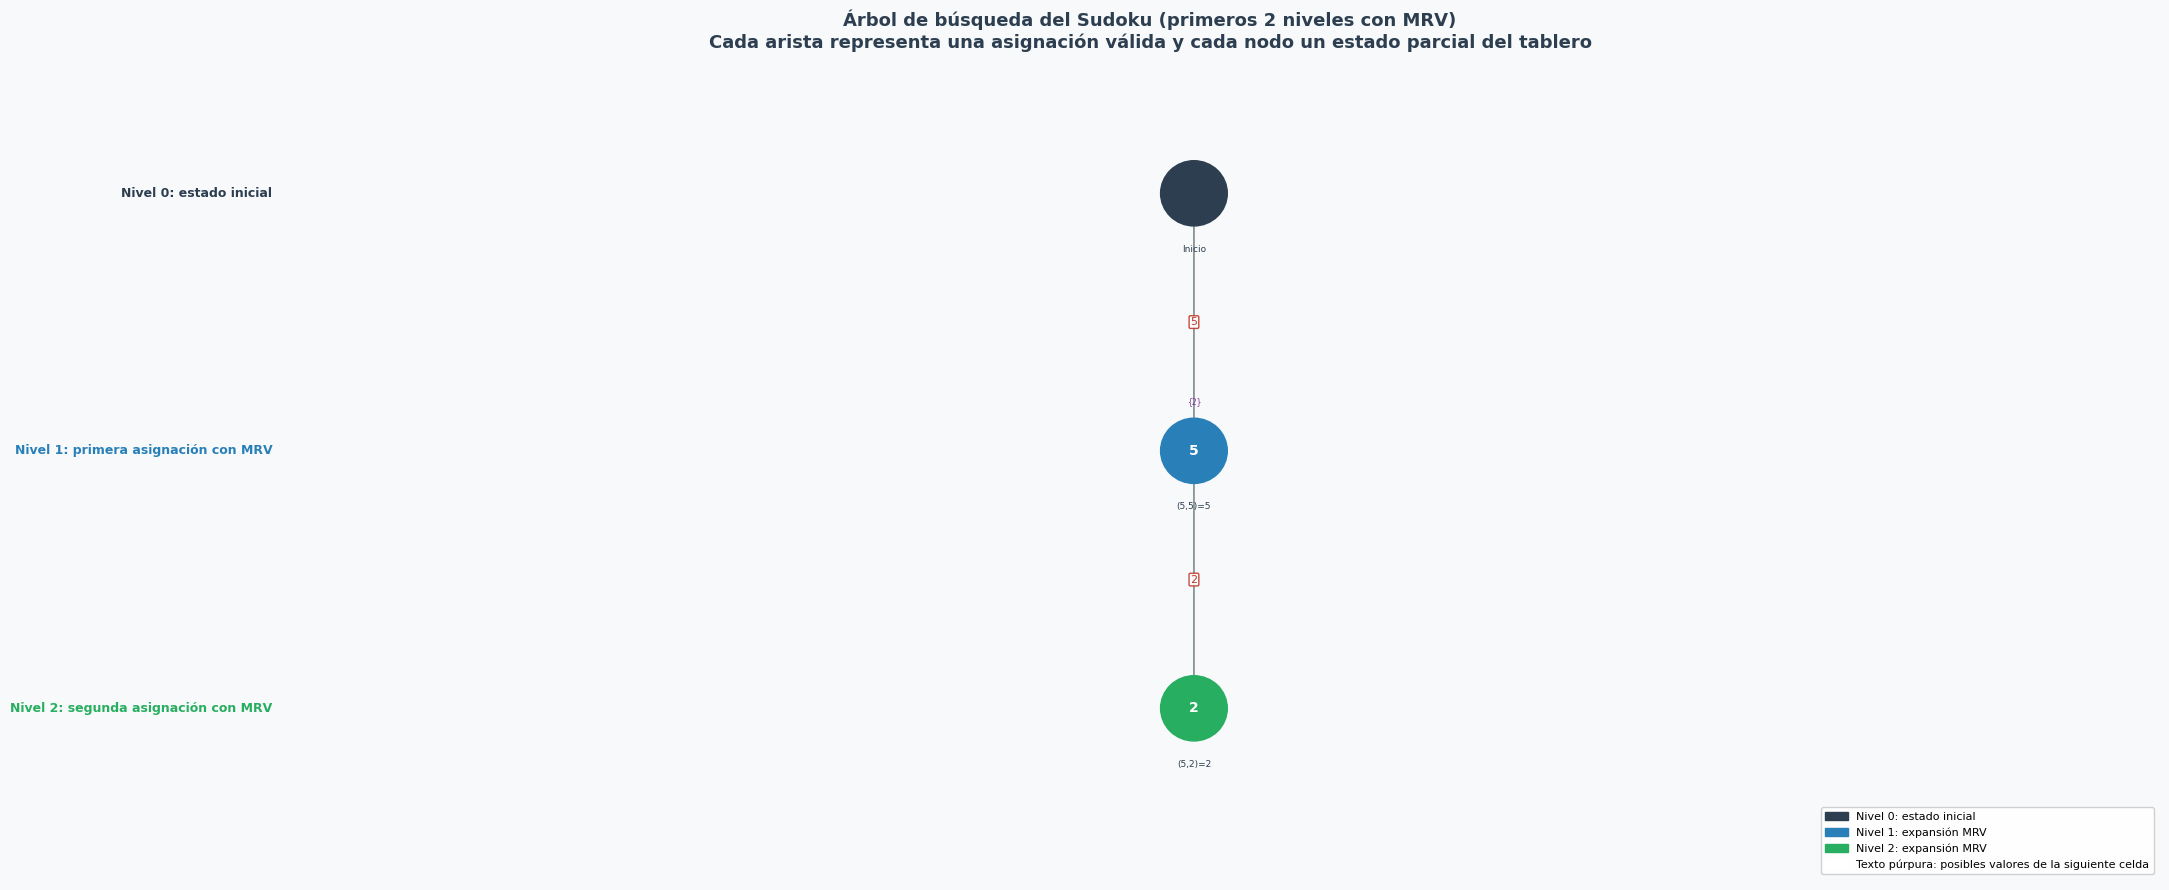

Árbol de búsqueda guardado en la carpeta de imágenes.


In [5]:
# ============================================================
# Construcción y visualización de los primeros niveles del árbol
# ============================================================
def build_search_tree_sudoku(board, depth=2):
    """Construye los primeros niveles del árbol de búsqueda usando MRV."""
    nodes = []
    edges = []
    node_id = 0

    root_cell = find_empty_mrv(board)
    root_possible = get_possible_values(board, *root_cell) if root_cell else set()
    nodes.append({
        'id': 0,
        'level': 0,
        'cell': None,
        'value': None,
        'pv': root_possible,
        'board': copy.deepcopy(board),
        'label': 'Inicio',
    })

    queue = [(0, copy.deepcopy(board), 0)]

    while queue:
        parent_id, parent_board, parent_level = queue.pop(0)
        if parent_level >= depth:
            continue

        cell = find_empty_mrv(parent_board)
        if cell is None:
            continue

        row, col = cell
        possible_values = sorted(get_possible_values(parent_board, row, col))

        for value in possible_values:
            node_id += 1
            new_board = copy.deepcopy(parent_board)
            new_board[row][col] = value

            next_cell = find_empty_mrv(new_board)
            next_possible = get_possible_values(new_board, *next_cell) if next_cell else set()

            nodes.append({
                'id': node_id,
                'level': parent_level + 1,
                'cell': (row, col),
                'value': value,
                'pv': next_possible,
                'board': new_board,
                'label': f'({row + 1},{col + 1})={value}',
            })
            edges.append((parent_id, node_id, value))

            if parent_level + 1 < depth:
                queue.append((node_id, new_board, parent_level + 1))

    return nodes, edges

tree_nodes, tree_edges = build_search_tree_sudoku(board_initial, depth=2)

print(f'Nodos generados (profundidad 2): {len(tree_nodes)}')
print(f'Aristas generadas: {len(tree_edges)}')
print()
print('Estructura resumida del árbol:')
for level in range(3):
    nodes_at_level = [node for node in tree_nodes if node['level'] == level]
    print(f'  Nivel {level}: {len(nodes_at_level)} nodo(s)')
    for node in nodes_at_level[:6]:
        extra = f" | próximos valores: {sorted(node['pv'])}" if node['pv'] else ''
        print(f"    [{node['id']}] {node['label']}{extra}")
    if len(nodes_at_level) > 6:
        print(f'    ... y {len(nodes_at_level) - 6} más')

level_colors = {0: '#2C3E50', 1: '#2980B9', 2: '#27AE60'}
level_nodes_map = defaultdict(list)
for node in tree_nodes:
    level_nodes_map[node['level']].append(node)

positions = {}
y_gap = 3.0
for level, nodes_at_level in level_nodes_map.items():
    x_gap = 20.0 / max(len(nodes_at_level), 1)
    for index, node in enumerate(nodes_at_level):
        positions[node['id']] = (x_gap * index + x_gap / 2, -level * y_gap)

fig, ax = plt.subplots(figsize=(22, 9))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

for parent_id, child_id, value in tree_edges:
    x1, y1 = positions[parent_id]
    x2, y2 = positions[child_id]
    ax.annotate(
        '', xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', color='#7F8C8D', lw=1.2)
    )
    middle_x, middle_y = (x1 + x2) / 2, (y1 + y2) / 2
    ax.text(
        middle_x, middle_y, str(value), fontsize=8, color='#C0392B',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.12', facecolor='white', edgecolor='#C0392B', alpha=0.9)
    )

for node in tree_nodes:
    x, y = positions[node['id']]
    level = node['level']
    color = level_colors.get(level, '#95A5A6')

    circle = plt.Circle((x, y), 0.38, color=color, zorder=5)
    ax.add_patch(circle)

    short_text = str(node['value']) if node['value'] is not None else ''
    ax.text(x, y, short_text, fontsize=10, fontweight='bold', ha='center', va='center', color='white', zorder=6)
    ax.text(x, y - 0.60, node['label'], fontsize=6.5, ha='center', va='top', color='#2C3E50')

    if level == 1 and node['pv']:
        pv_text = '{' + ','.join(map(str, sorted(node['pv']))) + '}'
        ax.text(x, y + 0.52, pv_text, fontsize=5.5, ha='center', va='bottom', color='#7D3C98')

level_labels = {
    0: 'Nivel 0: estado inicial',
    1: 'Nivel 1: primera asignación con MRV',
    2: 'Nivel 2: segunda asignación con MRV',
}
for level in range(3):
    if level_nodes_map[level]:
        ax.text(
            -0.5, -level * y_gap, level_labels[level], fontsize=9,
            color=level_colors[level], ha='right', va='center', fontweight='bold'
        )

legend_elements = [
    mpatches.Patch(color=level_colors[0], label='Nivel 0: estado inicial'),
    mpatches.Patch(color=level_colors[1], label='Nivel 1: expansión MRV'),
    mpatches.Patch(color=level_colors[2], label='Nivel 2: expansión MRV'),
    mpatches.Patch(color='white', label='Texto púrpura: posibles valores de la siguiente celda'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

ax.set_xlim(-2, 21)
ax.set_ylim(-8, 1.5)
ax.axis('off')
ax.set_title(
    'Árbol de búsqueda del Sudoku (primeros 2 niveles con MRV)\n'
    'Cada arista representa una asignación válida y cada nodo un estado parcial del tablero',
    fontsize=13, fontweight='bold', pad=12, color='#2C3E50'
)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'arbol_busqueda_sudoku.png', dpi=150, bbox_inches='tight')
plt.show()
print('Árbol de búsqueda guardado en la carpeta de imágenes.')

---
## 6. Resolución: backtracking con MRV

El algoritmo de **backtracking** realiza una búsqueda en profundidad con poda:
1. Elegir la celda vacía con menos valores posibles mediante MRV.
2. Intentar cada valor válido.
3. Si se alcanza un estado inconsistente, retroceder.
4. Si no quedan celdas vacías, se encontró una solución.

La poda elimina ramas inviables tempranamente, haciendo el procedimiento práctico para esta instancia.

In [6]:
# ============================================================
# Solucionador por backtracking con MRV
# ============================================================
call_count = [0]
assignment_trace = []

def solve_sudoku(board):
    """Resuelve el Sudoku por backtracking con heurística MRV."""
    call_count[0] += 1

    cell = find_empty_mrv(board)
    if cell is None:
        return True

    row, col = cell
    possible_values = sorted(get_possible_values(board, row, col))
    if not possible_values:
        return False

    for value in possible_values:
        board[row][col] = value
        assignment_trace.append((row, col, value))

        if solve_sudoku(board):
            return True

        assignment_trace.pop()
        board[row][col] = 0

    return False

call_count[0] = 0
assignment_trace.clear()
solution = copy.deepcopy(board_initial)
found = solve_sudoku(solution)

print(f'Solución encontrada: {found}')
print(f'Llamadas recursivas: {call_count[0]:,}')
print(f'Conflictos en la solución: {count_conflicts(solution)}')
print()
print('Solución obtenida:')
for row in solution:
    print(' '.join(map(str, row)))

Solución encontrada: True
Llamadas recursivas: 52
Conflictos en la solución: 0

Solución obtenida:
5 3 4 6 7 8 9 1 2
6 7 2 1 9 5 3 4 8
1 9 8 3 4 2 5 6 7
8 5 9 7 6 1 4 2 3
4 2 6 8 5 3 7 9 1
7 1 3 9 2 4 8 5 6
9 6 1 5 3 7 2 8 4
2 8 7 4 1 9 6 3 5
3 4 5 2 8 6 1 7 9


### 6.1 Visualización del tablero inicial y la solución

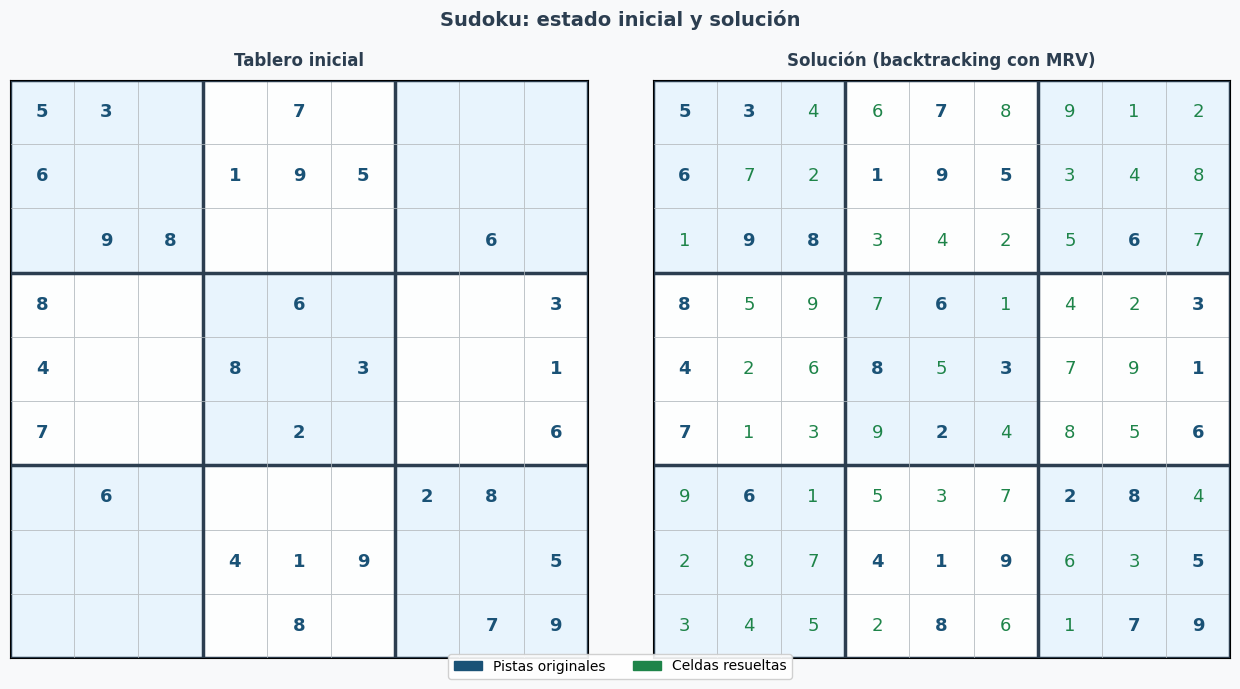

Figura comparativa guardada en la carpeta de imágenes.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
fig.patch.set_facecolor('#F8F9FA')

draw_sudoku(
    board_initial,
    title='Tablero inicial',
    given_board=board_initial,
    ax=axes[0],
)

draw_sudoku(
    solution,
    title='Solución (backtracking con MRV)',
    given_board=board_initial,
    ax=axes[1],
)

blue_patch = mpatches.Patch(color='#1A5276', label='Pistas originales')
green_patch = mpatches.Patch(color='#1E8449', label='Celdas resueltas')
fig.legend(
    handles=[blue_patch, green_patch],
    loc='lower center', ncol=2, fontsize=10,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.02)
)

plt.suptitle(
    'Sudoku: estado inicial y solución',
    fontsize=14, fontweight='bold', color='#2C3E50', y=1.02
)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'sudoku_inicial_solucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura comparativa guardada en la carpeta de imágenes.')

---
## 7. Visualización de la función de costo durante la búsqueda

Para mostrar la evolución de la métrica $f(M)$, se reconstruye el orden de llenado siguiendo la misma heurística MRV y se agrega en cada paso el valor correspondiente de la solución encontrada.

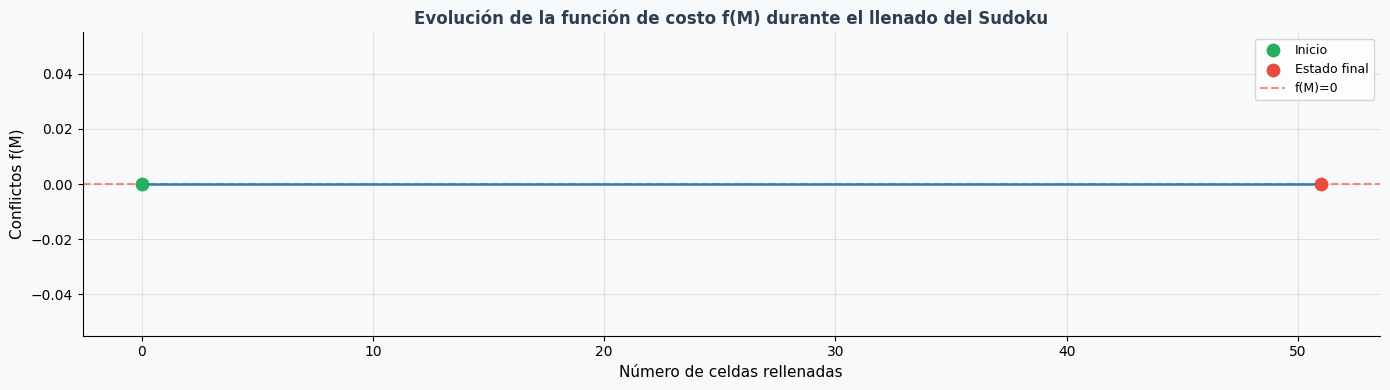

Gráfica de evolución guardada en la carpeta de imágenes.


In [8]:
# ============================================================
# Evolución de la función de costo durante una construcción consistente
# ============================================================
def reconstruct_fill_order(initial_board, solved_board):
    """Reconstruye el orden de llenado siguiendo MRV sobre la solución final."""
    working_board = copy.deepcopy(initial_board)
    order = []

    while True:
        cell = find_empty_mrv(working_board)
        if cell is None:
            break

        row, col = cell
        value = solved_board[row][col]
        order.append((row, col, value))
        working_board[row][col] = value

    return order

fill_order = reconstruct_fill_order(board_initial, solution)
progressive = copy.deepcopy(board_initial)
conflict_history = [count_conflicts(progressive)]

for row, col, value in fill_order:
    progressive[row][col] = value
    conflict_history.append(count_conflicts(progressive))

steps = list(range(len(conflict_history)))
fig, ax = plt.subplots(figsize=(14, 4))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

ax.plot(steps, conflict_history, color='#2980B9', linewidth=1.8, zorder=3)
ax.fill_between(steps, conflict_history, alpha=0.15, color='#2980B9')
ax.scatter([0], [conflict_history[0]], color='#27AE60', s=80, zorder=5, label='Inicio')
ax.scatter([len(steps) - 1], [conflict_history[-1]], color='#E74C3C', s=80, zorder=5, label='Estado final')
ax.axhline(0, color='#E74C3C', linestyle='--', alpha=0.6, label='f(M)=0')
ax.set_xlabel('Número de celdas rellenadas', fontsize=11)
ax.set_ylabel('Conflictos f(M)', fontsize=11)
ax.set_title(
    'Evolución de la función de costo f(M) durante el llenado del Sudoku',
    fontsize=12, fontweight='bold', color='#2C3E50'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'sudoku_costo_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica de evolución guardada en la carpeta de imágenes.')

---
## 8. Verificación de la solución

In [9]:
def verify_sudoku(board):
    """Verifica que el tablero sea una solución válida de Sudoku."""
    expected = set(range(1, 10))
    rows_ok = True
    cols_ok = True
    boxes_ok = True

    print('Verificación de la solución:')
    print('-' * 40)

    for row in range(9):
        if set(board[row]) != expected:
            print(f'Fila {row + 1} inválida: {board[row]}')
            rows_ok = False
    print('Filas: todas válidas' if rows_ok else 'Filas: hay errores')

    for col in range(9):
        column = [board[row][col] for row in range(9)]
        if set(column) != expected:
            print(f'Columna {col + 1} inválida: {column}')
            cols_ok = False
    print('Columnas: todas válidas' if cols_ok else 'Columnas: hay errores')

    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            box = [
                board[r][c]
                for r in range(box_row, box_row + 3)
                for c in range(box_col, box_col + 3)
            ]
            if set(box) != expected:
                print(f'Subcuadro ({box_row // 3 + 1},{box_col // 3 + 1}) inválido: {box}')
                boxes_ok = False
    print('Subcuadros: todos válidos' if boxes_ok else 'Subcuadros: hay errores')

    all_ok = rows_ok and cols_ok and boxes_ok
    print('-' * 40)
    print('Resultado: solución válida' if all_ok else 'Resultado: solución inválida')
    return all_ok

verify_sudoku(solution)

Verificación de la solución:
----------------------------------------
Filas: todas válidas
Columnas: todas válidas
Subcuadros: todos válidos
----------------------------------------
Resultado: solución válida


True

---
## 9. Resumen formal

| Componente | Descripción |
|---|---|
| **Espacio $\Omega$** | Todas las formas de rellenar las $k$ celdas vacías con valores en $\{1,\ldots,9\}$ |
| **$|\Omega|$** | $9^k$ sin restricciones; para este tablero $9^{51} \approx 4.64 \times 10^{48}$ |
| **Representación** | Matriz $M \in \{0,\ldots,9\}^{9\times9}$, donde $0$ representa una celda vacía |
| **Función de costo** | $f(M)$ = total de repeticiones en filas, columnas y subcuadros |
| **Objetivo** | Encontrar $M^*$ tal que $f(M^*) = 0$ |
| **Estado inicial** | Matriz con 30 pistas y 51 celdas vacías |
| **Estado meta** | Matriz completamente llena y sin conflictos |
| **Transición** | Asignar un valor válido $v$ a una celda vacía $(i,j)$ |
| **Poda** | Descartar asignaciones que violan fila, columna o subcuadro |
| **Heurística** | MRV: elegir la celda con menos valores posibles |
| **Algoritmo** | Backtracking en profundidad con MRV |
| **Llamadas recursivas** | Se reportan en la sección de resultados |

### Observaciones
- El Sudoku es un **CSP (Constraint Satisfaction Problem)**.
- La heurística **MRV** reduce el factor de ramificación al priorizar las decisiones más restringidas.
- En una construcción consistente guiada por restricciones, la función de costo se mantiene en 0 durante todo el proceso de llenado.